In [ ]:
from __future__ import annotations

import copy
import json
import math
import pickle
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch.optim import AdamW
from tqdm.auto import tqdm

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool
from torch_geometric.utils import dropout_edge

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

@dataclass(slots=True)
class PhaseEConfig:
    project_root: Path
    seed: int = 42

    processed_graphs_file: str = "outputs/processed_graphs/all_graphs.pkl"
    dataset_index_csv: str = "outputs/processed_graphs/dataset_index.csv"
    master_csv: str = "outputs/dataset_master.csv"

    graph_embeddings_dir: str = "outputs/graph_embeddings"
    model_dir: str = "outputs/graph_embeddings/models"
    embedding_dir: str = "outputs/graph_embeddings/embeddings"
    figure_dir: str = "outputs/graph_embeddings/figures"

    embedding_dim: int = 128
    hidden_dim: int = 128
    projection_dim: int = 64
    num_message_passing_layers: int = 3
    dropout: float = 0.10

    batch_size: int = 64
    num_epochs: int = 100
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    temperature: float = 0.20

    feature_mask_prob: float = 0.10
    edge_dropout_prob: float = 0.15
    pos_noise_std: float = 0.02

    tsne_perplexity: int = 30
    num_neighbors_to_inspect: int = 5

    @property
    def processed_graphs_path(self) -> Path:
        return self.project_root / self.processed_graphs_file

    @property
    def dataset_index_path(self) -> Path:
        return self.project_root / self.dataset_index_csv

    @property
    def master_path(self) -> Path:
        return self.project_root / self.master_csv

    @property
    def graph_embeddings_path(self) -> Path:
        return self.project_root / self.graph_embeddings_dir

    @property
    def model_path(self) -> Path:
        return self.project_root / self.model_dir

    @property
    def embedding_path(self) -> Path:
        return self.project_root / self.embedding_dir

    @property
    def figure_path(self) -> Path:
        return self.project_root / self.figure_dir

    @property
    def best_model_file(self) -> Path:
        return self.model_path / "ssl_gnn_best.pt"

    @property
    def final_model_file(self) -> Path:
        return self.model_path / "ssl_gnn_last.pt"

    @property
    def history_file(self) -> Path:
        return self.graph_embeddings_path / "training_history.csv"

    @property
    def config_file(self) -> Path:
        return self.graph_embeddings_path / "graph_embeddings_config.json"

    @property
    def embeddings_csv_file(self) -> Path:
        return self.embedding_path / "structure_embeddings.csv"

    @property
    def embeddings_npy_file(self) -> Path:
        return self.embedding_path / "structure_embeddings.npy"

    @property
    def pca_csv_file(self) -> Path:
        return self.embedding_path / "embedding_pca_2d.csv"

    @property
    def umap_csv_file(self) -> Path:
        return self.embedding_path / "embedding_umap_2d.csv"

    @property
    def tsne_csv_file(self) -> Path:
        return self.embedding_path / "embedding_tsne_2d.csv"


CONFIG = PhaseEConfig(project_root=Path.cwd().resolve().parent)


def ensure_dirs(paths: list[Path]) -> None:
    for path in paths:
        path.mkdir(parents=True, exist_ok=True)


ensure_dirs(
    [
        CONFIG.graph_embeddings_path,
        CONFIG.model_path,
        CONFIG.embedding_path,
        CONFIG.figure_path,
    ]
)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("UMAP available:", HAS_UMAP)
print("Processed graph file:", CONFIG.processed_graphs_path)

Device: cpu
UMAP available: False
Processed graph file: D:\masters_project\outputs\processed_graphs\all_graphs.pkl


In [ ]:
def load_pickle(path: Path) -> Any:
    with open(path, "rb") as f:
        return pickle.load(f)


def save_json(data: dict[str, Any], path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, default=str)


def graph_dict_to_pyg_data(graph: dict[str, Any]) -> Data:
    x = torch.tensor(graph["x"], dtype=torch.float32)
    pos = torch.tensor(graph["pos"], dtype=torch.float32)
    edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)
    edge_attr = torch.tensor(graph["edge_attr"], dtype=torch.float32)

    pos_centered = pos - pos.mean(dim=0, keepdim=True)
    pos_scale = pos_centered.std(dim=0, keepdim=True).clamp_min(1e-6)
    pos_norm = pos_centered / pos_scale

    x_full = torch.cat([x, pos_norm], dim=1)

    metadata = graph.get("metadata", {})
    targets = graph.get("targets", {})

    data = Data(
        x=x_full,
        pos=pos,
        pos_norm=pos_norm,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y_energy=torch.tensor([float(targets.get("energy", np.nan))], dtype=torch.float32),
        y_delta_energy=torch.tensor([float(targets.get("delta_energy", np.nan))], dtype=torch.float32),
    )

    data.structure_id = str(graph["structure_id"])
    data.relative_cif_path = graph.get("relative_cif_path")
    data.lower_rotation = float(metadata.get("lower_rotation", np.nan))
    data.displacement = float(metadata.get("displacement", np.nan))
    data.upper_rotation = float(metadata.get("upper_rotation", np.nan))

    return data


def load_graph_embeddings_dataset(config: PhaseEConfig) -> list[Data]:
    raw_graphs = load_pickle(config.processed_graphs_path)
    dataset = [graph_dict_to_pyg_data(g) for g in raw_graphs]
    return dataset


dataset = load_graph_embeddings_dataset(CONFIG)
print("Total graphs loaded:", len(dataset))
print(dataset[0])
print("Node feature dimension:", dataset[0].x.shape[1])
print("Edge feature dimension:", dataset[0].edge_attr.shape[1])

Total graphs loaded: 2916
Data(x=[156, 7], edge_index=[2, 3814], edge_attr=[3814, 3], pos=[156, 3], pos_norm=[156, 3], y_energy=[1], y_delta_energy=[1], structure_id='L0_D0_U0', relative_cif_path='r0/t0/t0_0.cif', lower_rotation=0.0, displacement=0.0, upper_rotation=0.0)
Node feature dimension: 7
Edge feature dimension: 3


In [ ]:
class GraphAugmenter:
    def __init__(
        self,
        feature_mask_prob: float = 0.10,
        edge_dropout_prob: float = 0.15,
        pos_noise_std: float = 0.02,
    ) -> None:
        self.feature_mask_prob = feature_mask_prob
        self.edge_dropout_prob = edge_dropout_prob
        self.pos_noise_std = pos_noise_std

    def __call__(self, batch: Data) -> Data:
        out = copy.deepcopy(batch)

        if self.feature_mask_prob > 0:
            feature_mask = torch.rand_like(out.x) < self.feature_mask_prob
            out.x = out.x.masked_fill(feature_mask, 0.0)

        if self.pos_noise_std > 0:
            noise = torch.randn_like(out.pos_norm) * self.pos_noise_std
            out.x[:, -3:] = out.x[:, -3:] + noise

        if self.edge_dropout_prob > 0 and out.edge_index.numel() > 0:
            edge_index_new, edge_mask = dropout_edge(
                out.edge_index,
                p=self.edge_dropout_prob,
                force_undirected=False,
                training=True,
            )
            out.edge_index = edge_index_new
            out.edge_attr = out.edge_attr[edge_mask]

        return out


augmenter = GraphAugmenter(
    feature_mask_prob=CONFIG.feature_mask_prob,
    edge_dropout_prob=CONFIG.edge_dropout_prob,
    pos_noise_std=CONFIG.pos_noise_std,
)

train_loader = DataLoader(dataset, batch_size=CONFIG.batch_size, shuffle=True)

In [4]:
class MLP(nn.Module):
    def __init__(self, dims: list[int], dropout: float = 0.0) -> None:
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SSLGNN(nn.Module):
    def __init__(
        self,
        node_in_dim: int,
        edge_in_dim: int,
        hidden_dim: int = 128,
        embedding_dim: int = 128,
        projection_dim: int = 64,
        num_layers: int = 3,
        dropout: float = 0.10,
    ) -> None:
        super().__init__()

        self.node_encoder = nn.Linear(node_in_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_in_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            conv_mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(conv_mlp, edge_dim=hidden_dim))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.dropout = dropout
        self.embedding_head = MLP([hidden_dim, hidden_dim, embedding_dim], dropout=dropout)
        self.projection_head = MLP([embedding_dim, hidden_dim, projection_dim], dropout=dropout)

    def encode(self, data: Data) -> torch.Tensor:
        x = self.node_encoder(data.x)
        e = self.edge_encoder(data.edge_attr)

        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, data.edge_index, e)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, data.batch)
        z = self.embedding_head(g)
        return z

    def project(self, z: torch.Tensor) -> torch.Tensor:
        return self.projection_head(z)

    def forward(self, data: Data) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encode(data)
        p = self.project(z)
        return z, p


def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.20) -> torch.Tensor:
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    similarity = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
    similarity = similarity.masked_fill(mask, -9e15)

    targets = torch.arange(batch_size, device=z.device)
    targets = torch.cat([targets + batch_size, targets], dim=0)

    loss = F.cross_entropy(similarity, targets)
    return loss


sample = next(iter(train_loader))
model = SSLGNN(
    node_in_dim=dataset[0].x.shape[1],
    edge_in_dim=dataset[0].edge_attr.shape[1],
    hidden_dim=CONFIG.hidden_dim,
    embedding_dim=CONFIG.embedding_dim,
    projection_dim=CONFIG.projection_dim,
    num_layers=CONFIG.num_message_passing_layers,
    dropout=CONFIG.dropout,
).to(DEVICE)

sample = sample.to(DEVICE)
z, p = model(sample)
print("Embedding shape:", z.shape)
print("Projection shape:", p.shape)

Embedding shape: torch.Size([64, 128])
Projection shape: torch.Size([64, 64])


In [5]:
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG.learning_rate,
    weight_decay=CONFIG.weight_decay,
)

history_rows: list[dict[str, float]] = []
best_loss = math.inf


def train_one_epoch(
    model: SSLGNN,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    augmenter: GraphAugmenter,
    temperature: float,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)
        batch_view_1 = augmenter(batch)
        batch_view_2 = augmenter(batch)

        _, proj_1 = model(batch_view_1)
        _, proj_2 = model(batch_view_2)

        loss = nt_xent_loss(proj_1, proj_2, temperature=temperature)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = batch.num_graphs
        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size

    return total_loss / max(total_graphs, 1)


for epoch in tqdm(range(1, CONFIG.num_epochs + 1), desc="training"):
    epoch_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        augmenter=augmenter,
        temperature=CONFIG.temperature,
        device=DEVICE,
    )

    history_rows.append({"epoch": epoch, "train_loss": epoch_loss})

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), CONFIG.best_model_file)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.6f}")

torch.save(model.state_dict(), CONFIG.final_model_file)

history_df = pd.DataFrame(history_rows)
history_df.to_csv(CONFIG.history_file, index=False)
dredge
save_json(asdict(CONFIG), CONFIG.config_file)

print("Best loss:", best_loss)
print("Best model:", CONFIG.best_model_file)
print("Last model:", CONFIG.final_model_file)
print("History:", CONFIG.history_file)

training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train_loss = 2.580702
Epoch 010 | train_loss = 1.528678
Epoch 020 | train_loss = 1.372024
Epoch 030 | train_loss = 1.304510
Epoch 040 | train_loss = 1.256131
Epoch 050 | train_loss = 1.226725
Epoch 060 | train_loss = 1.193273
Epoch 070 | train_loss = 1.177800
Epoch 080 | train_loss = 1.160254
Epoch 090 | train_loss = 1.149426
Epoch 100 | train_loss = 1.133223
Best loss: 1.133222524030709
Best model: D:\masters_project\outputs\graph_embeddings\models\ssl_gnn_best.pt
Last model: D:\masters_project\outputs\graph_embeddings\models\ssl_gnn_last.pt
History: D:\masters_project\outputs\graph_embeddings\training_history.csv


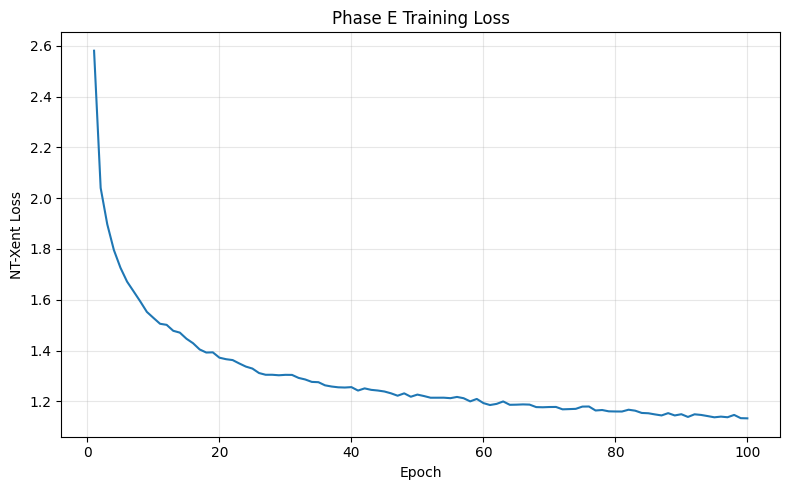

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"])
plt.title("Phase E Training Loss")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CONFIG.figure_path / "training_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
best_model = SSLGNN(
    node_in_dim=dataset[0].x.shape[1],
    edge_in_dim=dataset[0].edge_attr.shape[1],
    hidden_dim=CONFIG.hidden_dim,
    embedding_dim=CONFIG.embedding_dim,
    projection_dim=CONFIG.projection_dim,
    num_layers=CONFIG.num_message_passing_layers,
    dropout=CONFIG.dropout,
).to(DEVICE)

best_model.load_state_dict(torch.load(CONFIG.best_model_file, map_location=DEVICE))
best_model.eval()


@torch.no_grad()
def extract_embeddings(model: SSLGNN, dataset: list[Data], batch_size: int, device: torch.device) -> pd.DataFrame:
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    rows: list[dict[str, Any]] = []
    all_embeddings = []

    for batch in tqdm(loader, desc="Extracting embeddings"):
        batch = batch.to(device)
        z = model.encode(batch).cpu().numpy()
        batch_size_actual = batch.num_graphs

        structure_ids = batch.structure_id
        relative_paths = batch.relative_cif_path

        lower_rotation = batch.lower_rotation.cpu().numpy()
        displacement = batch.displacement.cpu().numpy()
        upper_rotation = batch.upper_rotation.cpu().numpy()
        energy = batch.y_energy.cpu().numpy().reshape(-1)
        delta_energy = batch.y_delta_energy.cpu().numpy().reshape(-1)

        for i in range(batch_size_actual):
            row = {
                "structure_id": structure_ids[i],
                "relative_cif_path": relative_paths[i],
                "lower_rotation": float(lower_rotation[i]),
                "displacement": float(displacement[i]),
                "upper_rotation": float(upper_rotation[i]),
                "energy": float(energy[i]),
                "delta_energy": float(delta_energy[i]),
            }
            for j in range(z.shape[1]):
                row[f"emb_{j:03d}"] = float(z[i, j])
            rows.append(row)

        all_embeddings.append(z)

    embedding_df = pd.DataFrame(rows)
    embedding_matrix = np.vstack(all_embeddings)
    np.save(CONFIG.embeddings_npy_file, embedding_matrix)
    embedding_df.to_csv(CONFIG.embeddings_csv_file, index=False)
    return embedding_df


embedding_df = extract_embeddings(
    model=best_model,
    dataset=dataset,
    batch_size=CONFIG.batch_size,
    device=DEVICE,
)

print(embedding_df.shape)
display(embedding_df.head())
print("Saved CSV:", CONFIG.embeddings_csv_file)
print("Saved NPY:", CONFIG.embeddings_npy_file)

Extracting embeddings:   0%|          | 0/46 [00:00<?, ?it/s]

(2916, 135)


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,emb_000,emb_001,emb_002,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,0.073159,0.141754,0.016134,...,-0.033409,-0.183279,-1.197514,0.843067,0.471116,1.374571,0.177294,-0.746185,1.760199,0.874277
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,-0.018456,1.128705,1.116602,...,0.632755,0.213688,-0.204751,0.297744,-0.041940,-0.160696,-0.433105,0.652352,0.022312,0.583544
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,-0.548361,1.584229,0.988826,...,-0.121449,-0.713889,-0.694005,0.529911,0.279335,0.524906,-0.802853,0.527694,0.579572,1.396550
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,-0.250084,0.888609,-0.177643,...,-0.133673,-0.617657,-0.444197,0.686531,-0.491393,1.036338,0.281228,-0.249501,1.038146,1.756115
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.080722,1.491669,-0.357859,...,-0.327856,-0.897027,-1.130939,0.477635,-0.421997,1.434749,-0.336113,-0.153849,1.540025,0.591750


Saved CSV: D:\masters_project\outputs\graph_embeddings\embeddings\structure_embeddings.csv
Saved NPY: D:\masters_project\outputs\graph_embeddings\embeddings\structure_embeddings.npy


In [ ]:
embedding_cols = [c for c in embedding_df.columns if c.startswith("emb_")]
X = embedding_df[embedding_cols].to_numpy(dtype=float)

pca = PCA(n_components=2, random_state=CONFIG.seed)
pca_2d = pca.fit_transform(X)

pca_df = embedding_df[
    ["structure_id", "relative_cif_path", "lower_rotation", "displacement", "upper_rotation", "energy", "delta_energy"]
].copy()
pca_df["pca_1"] = pca_2d[:, 0]
pca_df["pca_2"] = pca_2d[:, 1]
pca_df.to_csv(CONFIG.pca_csv_file, index=False)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

umap_df = None
if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.10,
        metric="cosine",
        random_state=CONFIG.seed,
    )
    umap_2d = reducer.fit_transform(X)

    umap_df = embedding_df[
        ["structure_id", "relative_cif_path", "lower_rotation", "displacement", "upper_rotation", "energy", "delta_energy"]
    ].copy()
    umap_df["umap_1"] = umap_2d[:, 0]
    umap_df["umap_2"] = umap_2d[:, 1]
    umap_df.to_csv(CONFIG.umap_csv_file, index=False)

tsne = TSNE(
    n_components=2,
    perplexity=min(CONFIG.tsne_perplexity, max(5, len(X) // 10)),
    random_state=CONFIG.seed,
    init="pca",
    learning_rate="auto",
)
tsne_2d = tsne.fit_transform(X)

tsne_df = embedding_df[
    ["structure_id", "relative_cif_path", "lower_rotation", "displacement", "upper_rotation", "energy", "delta_energy"]
].copy()
tsne_df["tsne_1"] = tsne_2d[:, 0]
tsne_df["tsne_2"] = tsne_2d[:, 1]
tsne_df.to_csv(CONFIG.tsne_csv_file, index=False)

print("Saved PCA:", CONFIG.pca_csv_file)
if HAS_UMAP:
    print("Saved UMAP:", CONFIG.umap_csv_file)
print("Saved t-SNE:", CONFIG.tsne_csv_file)

PCA explained variance ratio: [0.11995554 0.10885292]
Saved PCA: D:\masters_project\outputs\graph_embeddings\embeddings\embedding_pca_2d.csv
Saved t-SNE: D:\masters_project\outputs\graph_embeddings\embeddings\embedding_tsne_2d.csv


In [10]:
def scatter_plot(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    color_col: str,
    title: str,
    output_name: str,
    cmap: str = "viridis",
) -> None:
    plt.figure(figsize=(9, 7))
    sc = plt.scatter(df[x_col], df[y_col], c=df[color_col], s=22, alpha=0.85, cmap=cmap)
    plt.colorbar(sc, label=color_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(CONFIG.figure_path / output_name, dpi=200, bbox_inches="tight")
    plt.show()

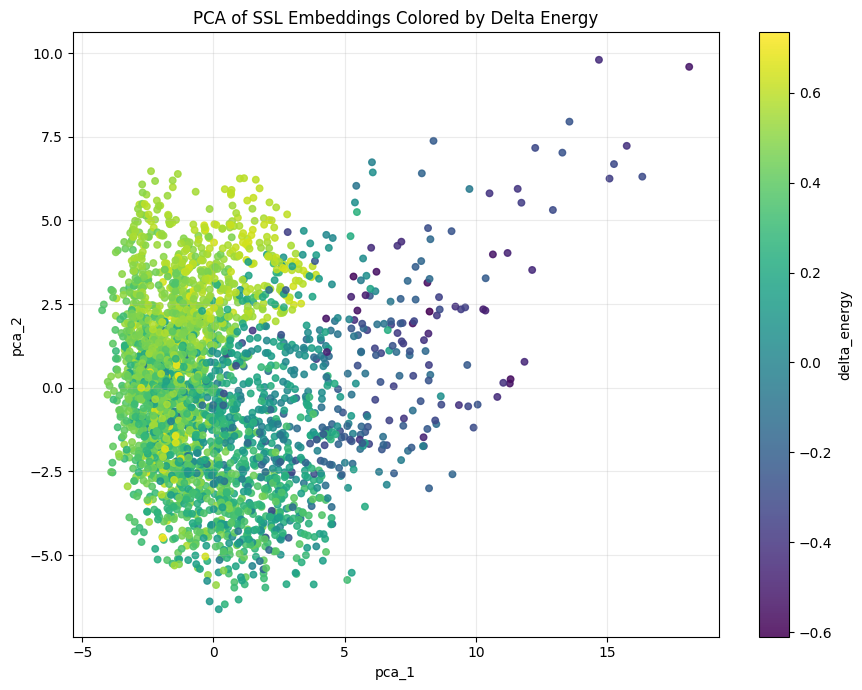

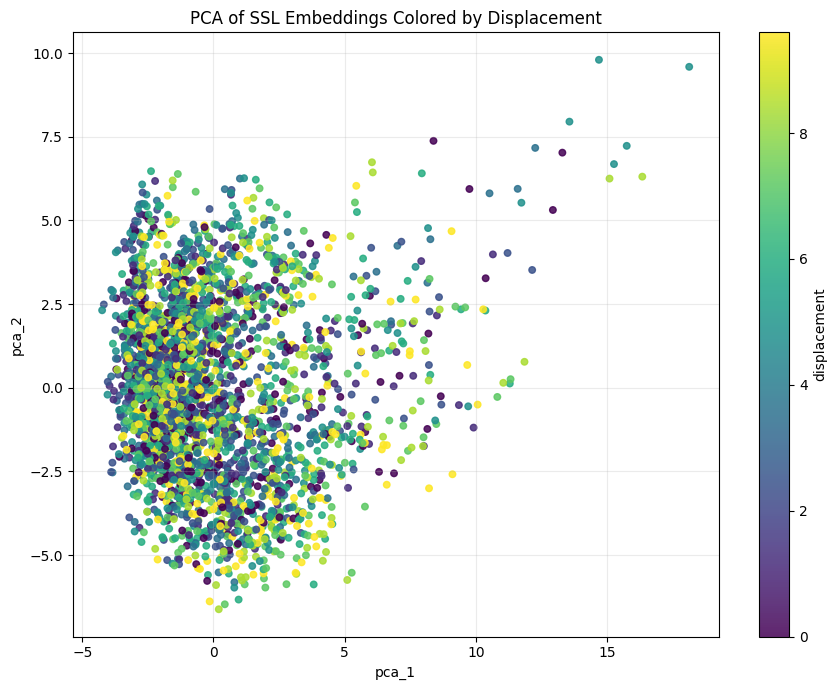

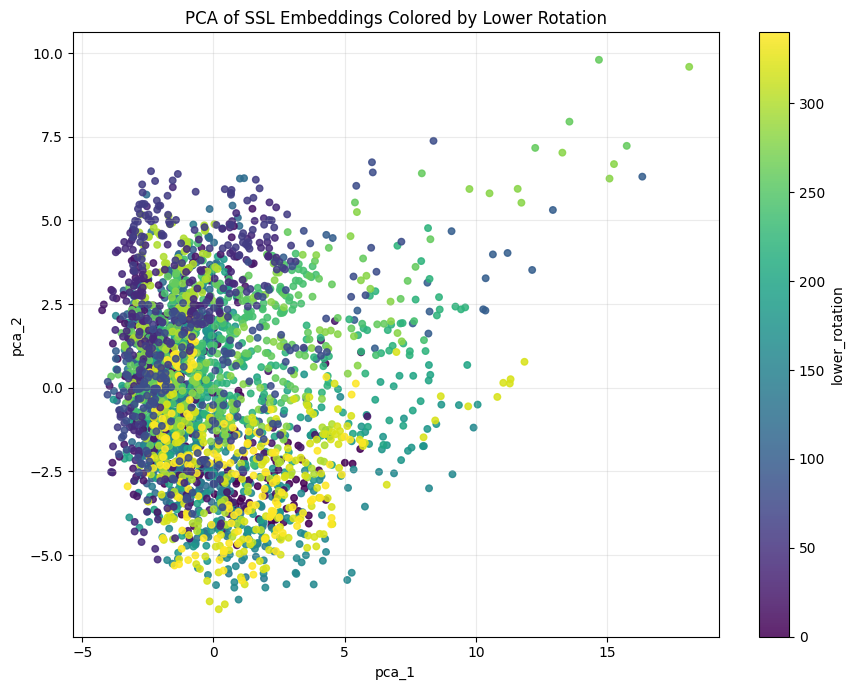

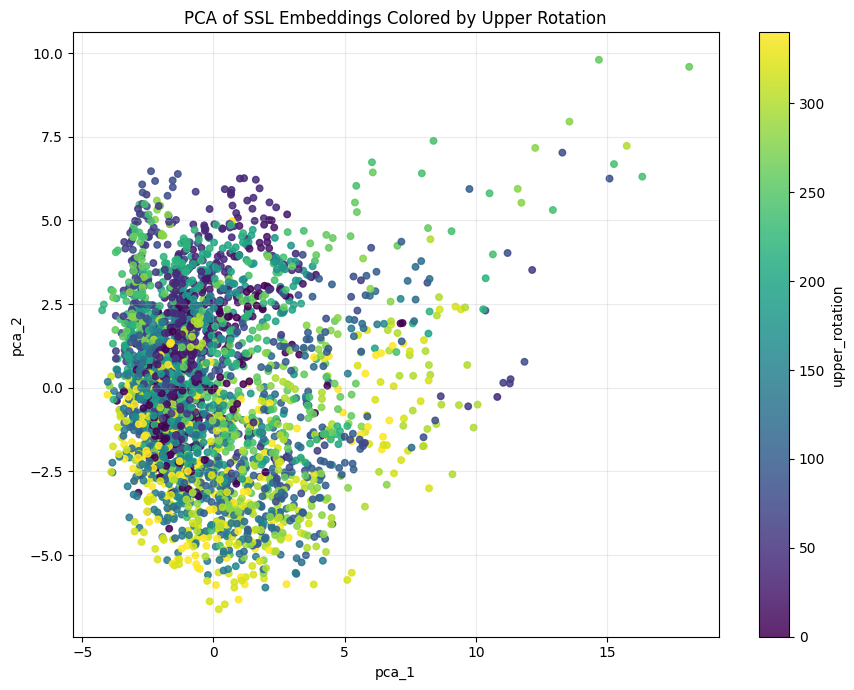

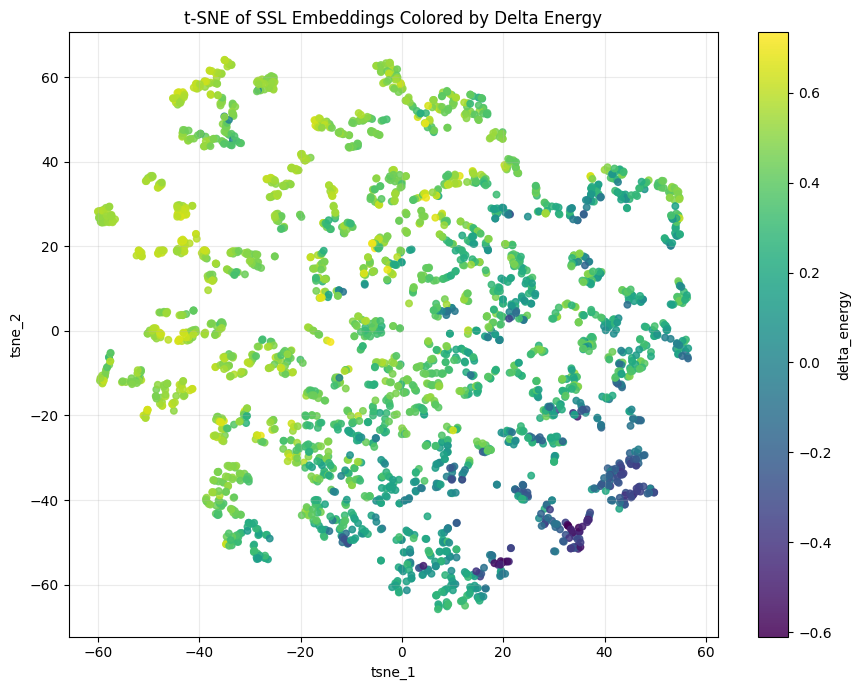

In [ ]:
scatter_plot(
    pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="delta_energy",
    title="PCA of SSL Embeddings Colored by Delta Energy",
    output_name="pca_colored_by_delta_energy.png",
)

# PCA colored by displacement
scatter_plot(
    pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="displacement",
    title="PCA of SSL Embeddings Colored by Displacement",
    output_name="pca_colored_by_displacement.png",
)

# PCA colored by lower rotation
scatter_plot(
    pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="lower_rotation",
    title="PCA of SSL Embeddings Colored by Lower Rotation",
    output_name="pca_colored_by_lower_rotation.png",
)

# PCA colored by upper rotation
scatter_plot(
    pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="upper_rotation",
    title="PCA of SSL Embeddings Colored by Upper Rotation",
    output_name="pca_colored_by_upper_rotation.png",
)

if HAS_UMAP and umap_df is not None:
    scatter_plot(
        umap_df,
        x_col="umap_1",
        y_col="umap_2",
        color_col="delta_energy",
        title="UMAP of SSL Embeddings Colored by Delta Energy",
        output_name="umap_colored_by_delta_energy.png",
    )

    scatter_plot(
        umap_df,
        x_col="umap_1",
        y_col="umap_2",
        color_col="displacement",
        title="UMAP of SSL Embeddings Colored by Displacement",
        output_name="umap_colored_by_displacement.png",
    )

scatter_plot(
    tsne_df,
    x_col="tsne_1",
    y_col="tsne_2",
    color_col="delta_energy",
    title="t-SNE of SSL Embeddings Colored by Delta Energy",
    output_name="tsne_colored_by_delta_energy.png",
)

In [12]:
similarity_matrix = cosine_similarity(X)

def inspect_neighbors(
    embedding_df: pd.DataFrame,
    similarity_matrix: np.ndarray,
    structure_id: str,
    top_k: int = 5,
) -> pd.DataFrame:
    idx_list = embedding_df.index[embedding_df["structure_id"] == structure_id].tolist()
    if not idx_list:
        raise ValueError(f"structure_id not found: {structure_id}")

    idx = idx_list[0]
    sims = similarity_matrix[idx].copy()
    order = np.argsort(-sims)

    neighbor_indices = [j for j in order if j != idx][:top_k]
    cols = [
        "structure_id",
        "lower_rotation",
        "displacement",
        "upper_rotation",
        "energy",
        "delta_energy",
    ]
    out = embedding_df.iloc[neighbor_indices][cols].copy()
    out.insert(1, "similarity", sims[neighbor_indices])
    return out.reset_index(drop=True)


# Example: inspect one structure
example_structure_id = embedding_df.iloc[0]["structure_id"]
neighbor_df = inspect_neighbors(
    embedding_df=embedding_df,
    similarity_matrix=similarity_matrix,
    structure_id=example_structure_id,
    top_k=CONFIG.num_neighbors_to_inspect,
)

print("Query structure:", example_structure_id)
display(neighbor_df)

Query structure: L0_D0_U0


,structure_id,similarity,lower_rotation,displacement,upper_rotation,energy,delta_energy
0,L0_D3.6_U340,0.920071,0.0,3.6,340.0,-936.516724,0.12306
1,L0_D7.2_U0,0.919891,0.0,7.2,0.0,-936.348267,0.29155
2,L0_D4.8_U340,0.915411,0.0,4.8,340.0,-936.538025,0.10177
3,L0_D0_U340,0.913198,0.0,0.0,340.0,-936.403442,0.23635
4,L0_D1.2_U340,0.911742,0.0,1.2,340.0,-936.412659,0.22714


In [15]:
summary = {
    "num_structures": int(len(embedding_df)),
    "embedding_dim": int(len(embedding_cols)),
    "mean_energy": float(embedding_df["energy"].mean()),
    "mean_delta_energy": float(embedding_df["delta_energy"].mean()),
    "std_delta_energy": float(embedding_df["delta_energy"].std()),
    "pca_var_ratio_1": float(pca.explained_variance_ratio_[0]),
    "pca_var_ratio_2": float(pca.explained_variance_ratio_[1]),
    "umap_available": bool(HAS_UMAP),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

summary_df.to_csv(CONFIG.graph_embeddings_path / "embedding_quality_summary.csv", index=False)
with open(CONFIG.graph_embeddings_path / "embedding_quality_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("complete.")
print("Main outputs:")
print("-", CONFIG.best_model_file)
print("-", CONFIG.embeddings_csv_file)
print("-", CONFIG.embeddings_npy_file)
print("-", CONFIG.figure_path)

,num_structures,embedding_dim,mean_energy,mean_delta_energy,std_delta_energy,pca_var_ratio_1,pca_var_ratio_2,umap_available
0,2916,128,-936.314189,0.325611,0.235972,0.119956,0.108853,False


complete.
Main outputs:
- D:\masters_project\outputs\graph_embeddings\models\ssl_gnn_best.pt
- D:\masters_project\outputs\graph_embeddings\embeddings\structure_embeddings.csv
- D:\masters_project\outputs\graph_embeddings\embeddings\structure_embeddings.npy
- D:\masters_project\outputs\graph_embeddings\figures


In [16]:
import umap

embedding_cols = [c for c in embedding_df.columns if c.startswith("emb_")]
X = embedding_df[embedding_cols].to_numpy(dtype=float)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.10,
    metric="cosine",
    random_state=CONFIG.seed,
)

umap_2d = reducer.fit_transform(X)

umap_df = embedding_df[
    [
        "structure_id",
        "relative_cif_path",
        "lower_rotation",
        "displacement",
        "upper_rotation",
        "energy",
        "delta_energy",
    ]
].copy()

umap_df["umap_1"] = umap_2d[:, 0]
umap_df["umap_2"] = umap_2d[:, 1]

umap_df.to_csv(CONFIG.umap_csv_file, index=False)

print("Saved UMAP:", CONFIG.umap_csv_file)

d:\masters_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved UMAP: D:\masters_project\outputs\graph_embeddings\embeddings\embedding_umap_2d.csv


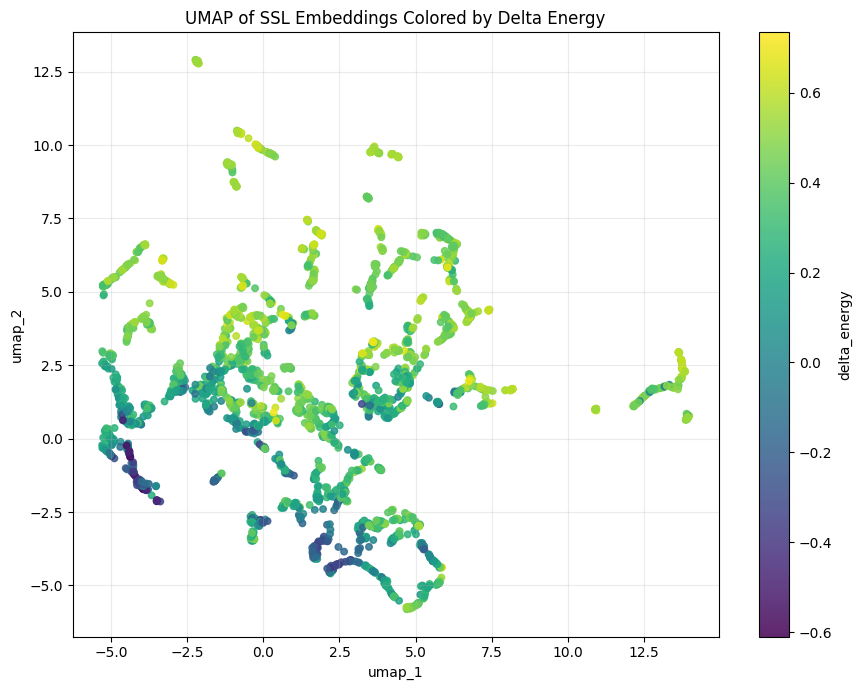

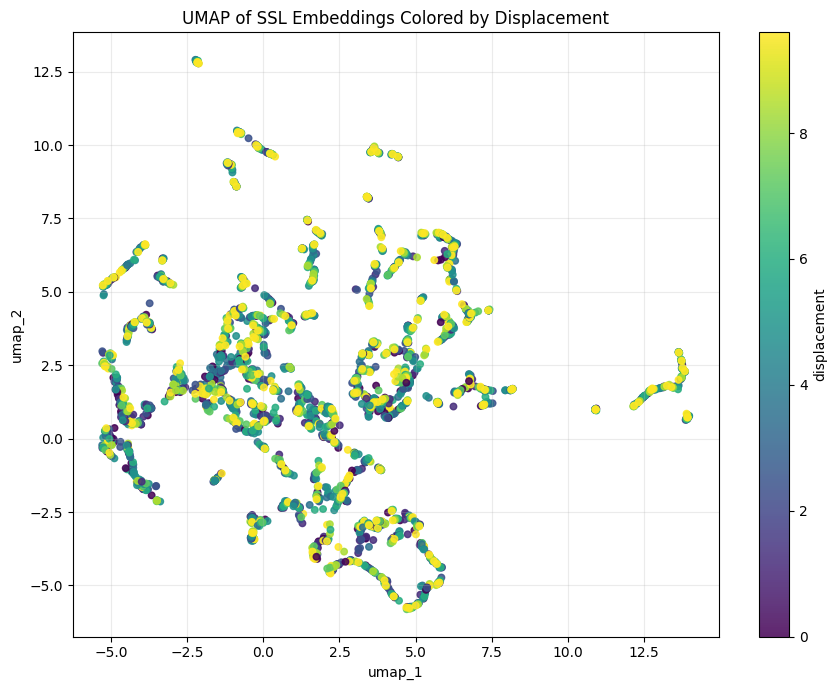

In [17]:
scatter_plot(
    umap_df,
    x_col="umap_1",
    y_col="umap_2",
    color_col="delta_energy",
    title="UMAP of SSL Embeddings Colored by Delta Energy",
    output_name="umap_colored_by_delta_energy.png",
)

scatter_plot(
    umap_df,
    x_col="umap_1",
    y_col="umap_2",
    color_col="displacement",
    title="UMAP of SSL Embeddings Colored by Displacement",
    output_name="umap_colored_by_displacement.png",
)